In [56]:
from google.colab import files
import io
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
upload = files.upload()

Saving battery_synthetic_dataset.csv to battery_synthetic_dataset.csv


In [37]:
data = pd.read_csv(io.BytesIO(upload["battery_synthetic_dataset.csv"]))

In [38]:
data.columns

Index(['avg_voltage', 'avg_temperature', 'battery_life_months', 'cycle_count',
       'label'],
      dtype='object')

In [39]:
x = data.drop("label",axis=1)
y = data["label"]

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [41]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [42]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 4)
(200, 4)
(800,)
(200,)


In [43]:
input_size = x_train.shape[1]
h1,h2,h3,h4,h5,h6,h7 = 5,6,8,4,7,10,15
output_size = 1

In [47]:
rng = np.random.default_rng(seed=42)
# Weights
w1 = rng.standard_normal((input_size,h1))
w2 = rng.standard_normal((h1,h2))
w3 = rng.standard_normal((h2,h3))
w4 = rng.standard_normal((h3,h4))
w5 = rng.standard_normal((h4,h5))
w6 = rng.standard_normal((h5,h6))
w7 = rng.standard_normal((h6,h7))
wo = rng.standard_normal((h7,output_size))
# Biases
b1 = np.zeros((1,h1))
b2 = np.zeros((1,h2))
b3 = np.zeros((1,h3))
b4 = np.zeros((1,h4))
b5 = np.zeros((1,h5))
b6 = np.zeros((1,h6))
b7 = np.zeros((1,h7))
bo = np.zeros((1,output_size))

In [45]:
def relu(x): return np.maximum(0,x)
def relu_driv(x):return np.where(x>0,1,0)

def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_driv(x): return sigmoid(x)*(1-sigmoid(x))

In [46]:
epochs = 1000
lr = 1e-3

In [51]:
for epoch in range(epochs):
  # Forward
  input = x_train

  h_1i = np.dot(input,w1) + b1
  h_1o = relu(h_1i)

  h_2i = np.dot(h_1o,w2) + b2
  h_2o = relu(h_2i)

  h_3i = np.dot(h_2o,w3) + b3
  h_3o = relu(h_3i)

  h_4i = np.dot(h_3o,w4) + b4
  h_4o = relu(h_4i)

  h_5i = np.dot(h_4o,w5) + b5
  h_5o = relu(h_5i)

  h_6i = np.dot(h_5o,w6) + b6
  h_6o = relu(h_6i)

  h_7i = np.dot(h_6o,w7) + b7
  h_7o = relu(h_7i)

  output_i = np.dot(h_7o,wo) + bo
  prediction = sigmoid(output_i)

  error = y_train.values.reshape(-1, 1) - prediction

  # Backward
  d_output = error * sigmoid_driv(prediction)
  d_h7 = np.dot(d_output,wo.T) * relu_driv(h_7o)
  d_h6 = np.dot(d_h7,w7.T) * relu_driv(h_6o)
  d_h5 = np.dot(d_h6,w6.T) * relu_driv(h_5o)
  d_h4 = np.dot(d_h5,w5.T) * relu_driv(h_4o)
  d_h3 = np.dot(d_h4,w4.T) * relu_driv(h_3o)
  d_h2 = np.dot(d_h3,w3.T) * relu_driv(h_2o)
  d_h1 = np.dot(d_h2,w2.T) * relu_driv(h_1o)

  # Gradiants
  go = np.dot(h_7o.T,d_output)
  g7 = np.dot(h_6o.T,d_h7)
  g6 = np.dot(h_5o.T,d_h6)
  g5 = np.dot(h_4o.T,d_h5)
  g4 = np.dot(h_3o.T,d_h4)
  g3 = np.dot(h_2o.T,d_h3)
  g2 = np.dot(h_1o.T,d_h2)
  g1 = np.dot(input.T,d_h1)

  # Weights update
  wo += go * lr
  w7 += g7 * lr
  w6 += g6 * lr
  w5 += g5 * lr
  w4 += g4 * lr
  w3 += g3 * lr
  w2 += g2 * lr
  w1 += g1 * lr

  # Biases update
  bo += np.sum(d_output) * lr
  b7 += np.sum(d_h7) * lr
  b6 += np.sum(d_h6) * lr
  b5 += np.sum(d_h5) * lr
  b4 += np.sum(d_h4) * lr
  b3 += np.sum(d_h3) * lr
  b2 += np.sum(d_h2) * lr
  b1 += np.sum(d_h1) * lr

  if (epoch + 1) % 100 == 0 or epoch == 0:
    loss = np.mean(np.square(error))
    print(f"Epoch {epoch+1}/{epochs}: Loss {loss}")


Epoch 1/1000: Loss 0.10918246702535576
Epoch 100/1000: Loss 0.10896784666272215
Epoch 200/1000: Loss 0.10896731068421962
Epoch 300/1000: Loss 0.10896658849630912
Epoch 400/1000: Loss 0.10896243979811927
Epoch 500/1000: Loss 0.10896216241129815
Epoch 600/1000: Loss 0.10896079200149124
Epoch 700/1000: Loss 0.10896452833290034
Epoch 800/1000: Loss 0.10896061554790441
Epoch 900/1000: Loss 0.10896159530264167
Epoch 1000/1000: Loss 0.10896148564322068


In [52]:
input = x_test
h_1 = relu(np.dot(input,w1) + b1)
h_2 = relu(np.dot(h_1,w2) + b2)
h_3 = relu(np.dot(h_2,w3) + b3)
h_4 = relu(np.dot(h_3,w4) + b4)
h_5 = relu(np.dot(h_4,w5) + b5)
h_6 = relu(np.dot(h_5,w6) + b6)
h_7 = relu(np.dot(h_6,w7) + b7)
prediction = sigmoid(np.dot(h_7,wo) + bo)

In [55]:
prediction_labels = (prediction > 0.5).astype(int)
print(classification_report(y_test, prediction_labels))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        73
           1       1.00      0.69      0.82       127

    accuracy                           0.81       200
   macro avg       0.83      0.85      0.80       200
weighted avg       0.87      0.81      0.81       200



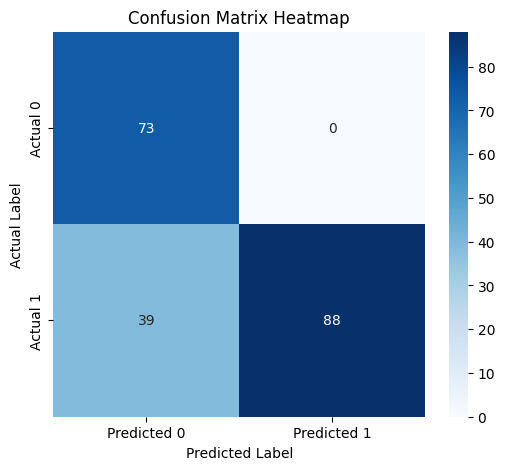

In [58]:
cm = confusion_matrix(y_test, prediction_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()